# 🎬 Movie Rating Prediction

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [25]:
movies_df = pd.read_csv("IMDb Movies India.csv", encoding='ISO-8859-1')
movies_df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [27]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


# Missing Values

In [30]:
movies_df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

# 🧹 Clean Votes and Clean Year

In [33]:
movies_df['Votes'] = movies_df['Votes'].astype(str).str.replace(',', '', regex=False)
movies_df['Votes'] = pd.to_numeric(movies_df['Votes'], errors='coerce')

In [35]:
movies_df['Year'] = movies_df['Year'].astype(str).str.extract(r'(\d+)')
movies_df['Year'] = pd.to_numeric(movies_df['Year'], errors='coerce')

In [37]:
movies_df['Duration'] = movies_df['Duration'].astype(str).str.replace(' min', '', regex=False)
movies_df['Duration'] = pd.to_numeric(movies_df['Duration'], errors='coerce')

# Fill Missing Values

In [40]:
movies_df = movies_df.fillna({
    'Votes': movies_df['Votes'].median(),
    'Year': movies_df['Year'].median(),
    'Duration': movies_df['Duration'].median(),
    'Rating': movies_df['Rating'].median(),
    'Genre': 'Unknown',
    'Director': 'Unknown',
    'Actor 1': 'Unknown',
    'Actor 2': 'Unknown',
    'Actor 3': 'Unknown'
})

# 📊 Top 10 Movies

In [43]:
top_movies = movies_df.sort_values(by='Rating', ascending=False).head(10)
top_movies[['Name','Rating']]

,Name,Rating
8339,Love Qubool Hai,10.0
5410,Half Songs,9.7
2563,Breed,9.6
11704,Ram-Path,9.4
14222,The Reluctant Crime,9.4
5077,Gho Gho Rani,9.4
6852,June,9.4
1314,Ashok Vatika,9.3
8344,Love Sorries,9.3
13231,Sindhustan,9.3


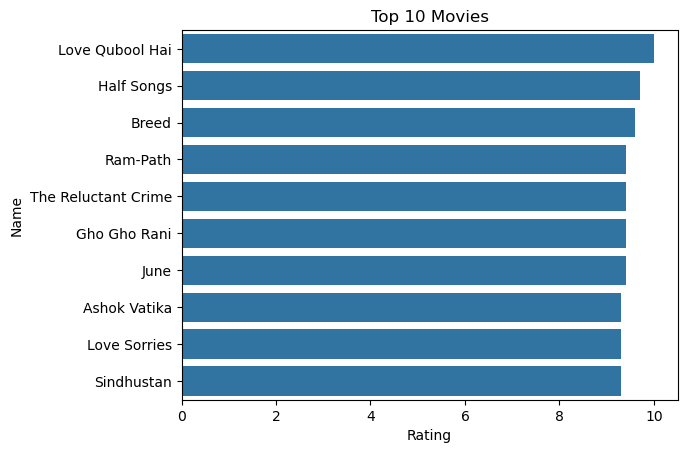

In [46]:
sns.barplot(x='Rating', y='Name', data=top_movies)
plt.title("Top 10 Movies")
plt.show()

# 📊 Top Movies by Year

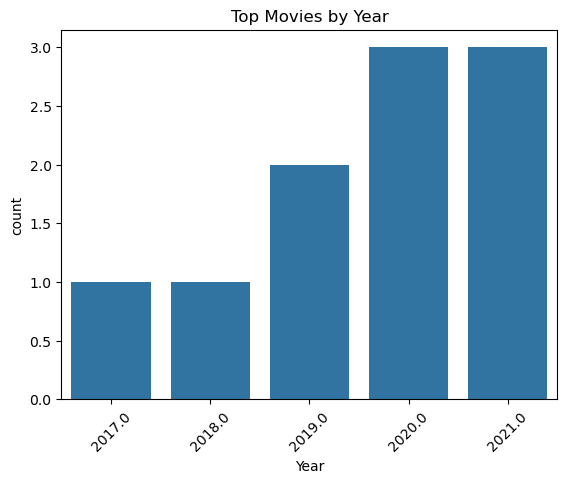

In [49]:
sns.countplot(x='Year', data=top_movies)
plt.xticks(rotation=45)
plt.title("Top Movies by Year")
plt.show()

# 📊 Genre Distribution

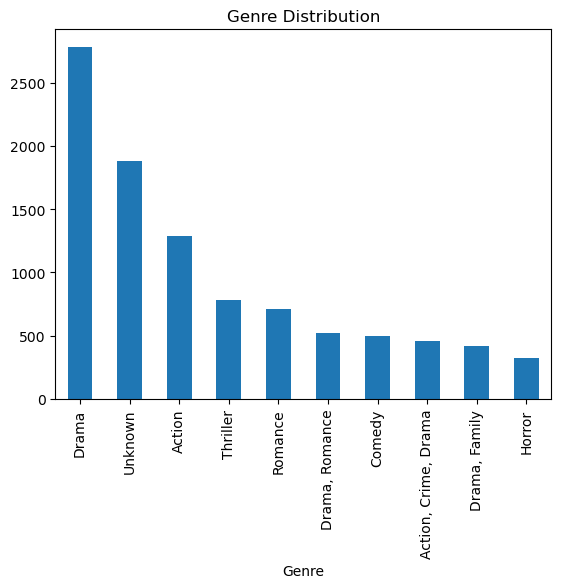

In [52]:
movies_df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Genre Distribution")
plt.show()

# 📊 Top Directors

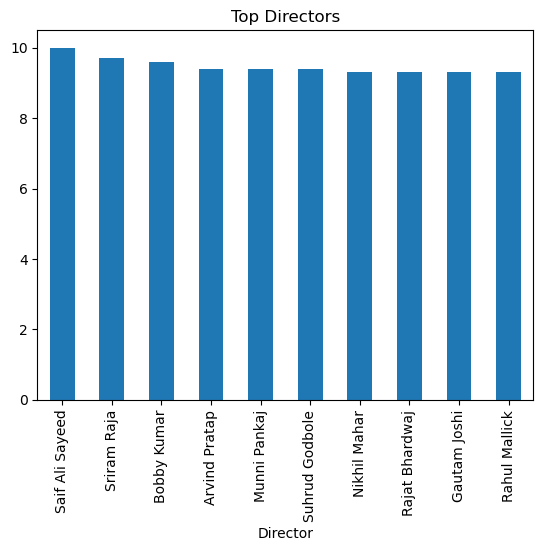

In [55]:
movies_df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Directors")
plt.show()

# 📊  Votes vs Rating

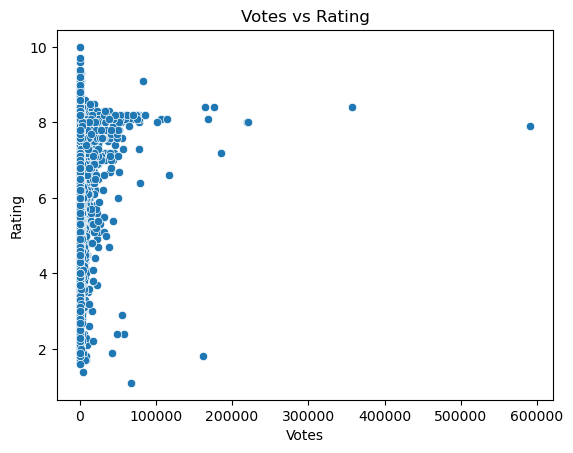

In [58]:
sns.scatterplot(x='Votes', y='Rating', data=movies_df)
plt.title("Votes vs Rating")
plt.show()

# 📊  Top Actors

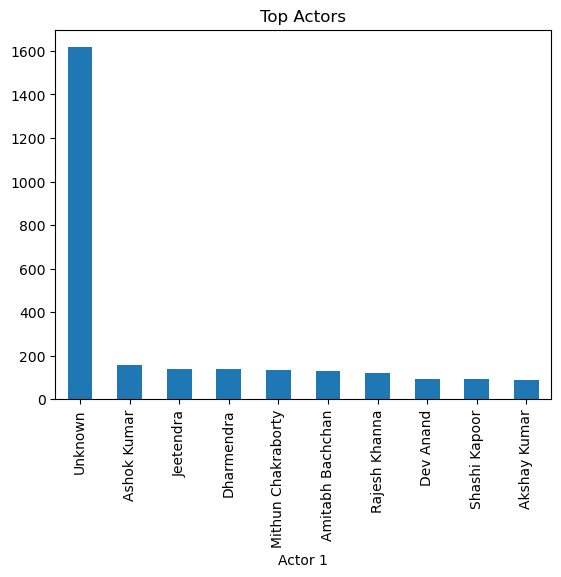

In [61]:
movies_df['Actor 1'].value_counts().head(10).plot(kind='bar')
plt.title("Top Actors")
plt.show()

# 📊  Movies per Year

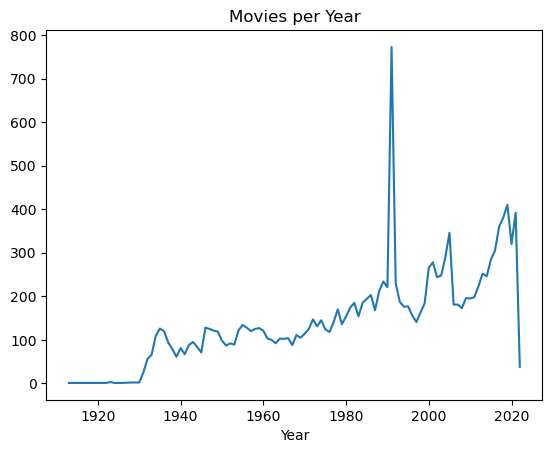

In [64]:
movies_df['Year'].value_counts().sort_index().plot()
plt.title("Movies per Year")
plt.show()

# 📊 High Rated Movies

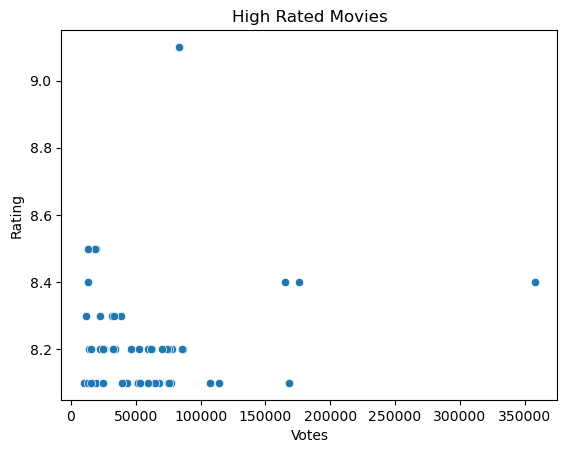

In [67]:
high_movies = movies_df[(movies_df['Rating'] > 8) & (movies_df['Votes'] > 10000)]
sns.scatterplot(x='Votes', y='Rating', data=high_movies)
plt.title("High Rated Movies")
plt.show()

# 📊 Duration vs Year

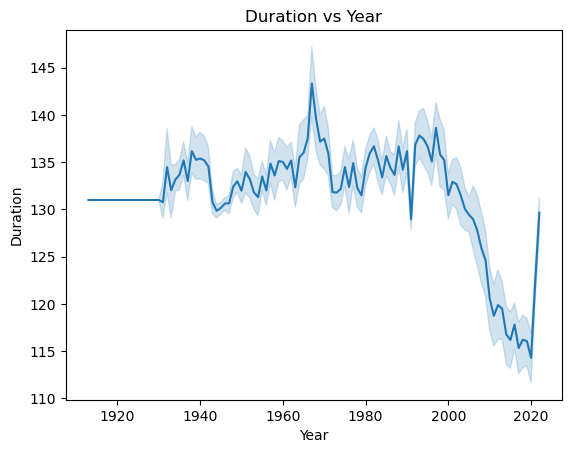

In [70]:
sns.lineplot(x='Year', y='Duration', data=movies_df)
plt.title("Duration vs Year")
plt.show()

# 📊  Average rating per Genre

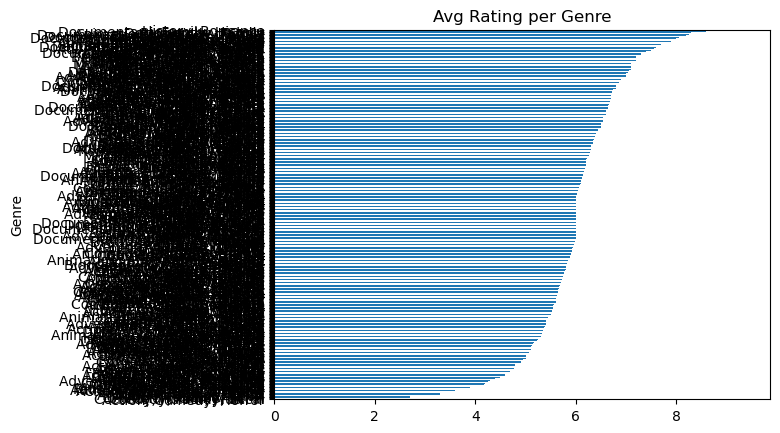

In [75]:
movies_df.groupby('Genre')['Rating'].mean().sort_values().plot(kind='barh')
plt.title("Avg Rating per Genre")
plt.show()

# ⚙️ Feature Engineering

In [79]:
movies_df = movies_df[['Year','Votes','Duration','Rating']]

# 📊 Correlation Heatmap

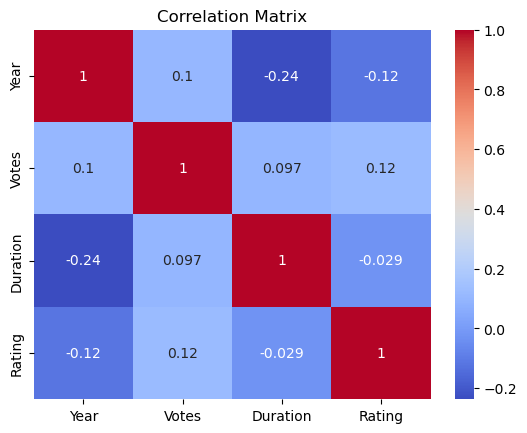

In [82]:
sns.heatmap(movies_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Train-Test Split

In [85]:
from sklearn.model_selection import train_test_split

X = movies_df[['Year','Votes','Duration']]
y = movies_df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model Training

In [88]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# 📈 Prediction and Evaluation

In [91]:
y_pred = model.predict(X_test)

In [93]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.9016302260576179


# 📊 Actual vs Predicted

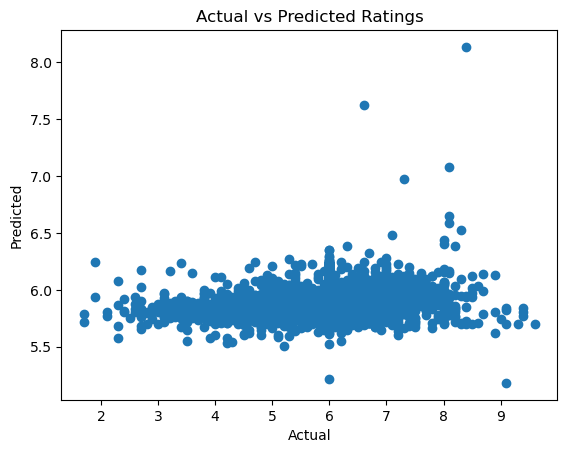

In [96]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Ratings")
plt.show()

### Conclusion

- Votes and duration influence movie ratings  
- Popular movies tend to have higher ratings  
- Linear regression provides reasonable predictions  